# AAI 540 Machine Learning Operations

## Fall 2026 Team Project: AWS SageMaker Implementation

**Project:** Turbofan Remaining Useful Life Prediction  
**Business name:** AeroReliability Analytics  
**Date:** September 20, 2026  
**Contributors:** Andrew Blumhardt and Dylan Scott-Dawkins  
**AI assistance:** ChatGPT assisted with organizing the notebook and drafting portions of the Python and AWS SDK code. The contributors are responsible for reviewing, testing, modifying, and explaining the final implementation and results.

### General description

This notebook adapts the team's local starter workflow to the AWS SageMaker student environment. It downloads the public NASA C-MAPSS FD001 dataset, copies the source data into Amazon S3, prepares Athena-compatible and Feature Store-compatible data, creates engine-level training, validation, test, and reserved production partitions, trains a simple benchmark, and provides an AWS-native SageMaker XGBoost training and Batch Transform workflow.

The notebook is intentionally staged. Local preparation cells can run first inside SageMaker Studio without creating managed AWS jobs. The configuration flags allow the team to enable Athena, Feature Store, SageMaker training, model registration, and Batch Transform one component at a time. This controls cost and makes permission errors easier to isolate in AWS Academy.

> Before final submission, execute the required AWS sections, preserve their outputs, and update the design document to match the resources and results actually used.

## Week 2 / Module 2: AWS Environment and Data Lake Foundation

This section establishes the SageMaker environment, retrieves the public project data, and creates the raw S3 data-lake layer. It corresponds to the AWS setup and Data Lake concepts practiced early in the course.

## 1. Environment and AWS session

This section confirms that the notebook is running with AWS credentials, discovers the SageMaker execution role, and selects the account's default SageMaker bucket. Resource names include a short account identifier so that two students can run the same notebook in separate Learner Lab accounts.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from io import BytesIO
from datetime import datetime, timezone
import json
import os
import platform
import shutil
import tarfile
import time
import zipfile

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import sagemaker
from sagemaker import Session, get_execution_role

region = boto3.Session().region_name or "us-east-1"
sts = boto3.client("sts", region_name=region)
account_id = sts.get_caller_identity()["Account"]
role = get_execution_role()
sm_session = Session()
bucket = os.getenv("AAI540_S3_BUCKET", sm_session.default_bucket())

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}; scikit-learn: {sklearn.__version__}; SageMaker SDK: {sagemaker.__version__}")
print(f"AWS region: {region}")
print(f"AWS account: ...{account_id[-4:]}")
print(f"SageMaker role: {role}")
print(f"Project bucket: s3://{bucket}")
print("AWS session initialized successfully.")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Python: 3.12.14
pandas: 2.3.3; scikit-learn: 1.7.2; SageMaker SDK: 2.257.6
AWS region: us-east-1
AWS account: ...6241
SageMaker role: arn:aws:iam::473047556241:role/LabRole
Project bucket: s3://sagemaker-us-east-1-473047556241
AWS session initialized successfully.


## 2. Project configuration and cost controls

Set a component flag to `True` only when you are ready to create or run that AWS resource. S3 uploads are inexpensive and enabled by default. The other stages are disabled initially so that the notebook can be tested through data preparation before consuming managed compute.

The notebook uses Batch Transform rather than a continuously running endpoint. This is better suited to periodic maintenance scoring and avoids leaving an endpoint active after the lab session.

In [19]:
PROJECT_PREFIX = "aai540-turbofan-rul"
RESOURCE_SUFFIX = account_id[-6:]
RANDOM_SEED = 42
RUL_CAP = 125
ROLLING_WINDOWS = (5, 10)
ROLLING_SENSOR_COUNT = 8

# Course-aligned engine-level split: 40% train, 10% validation, 10% test, 40% reserved production.
PARTITION_COUNTS = {"train": 40, "validation": 10, "test": 10, "production": 40}

# Turn these on sequentially after the preceding section succeeds.
UPLOAD_TO_S3 = True
RUN_ATHENA_SETUP = True
RUN_FEATURE_STORE = True
RUN_SAGEMAKER_TRAINING = True
RUN_MODEL_REGISTRATION = True
RUN_BATCH_TRANSFORM = True

LOCAL_ROOT = Path("aai540_turbofan")
RAW_DIR = LOCAL_ROOT / "raw" / "FD001"
PROCESSED_DIR = LOCAL_ROOT / "processed"
OUTPUT_DIR = LOCAL_ROOT / "outputs"
for directory in (RAW_DIR, PROCESSED_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Component flags:")
for name in ["UPLOAD_TO_S3", "RUN_ATHENA_SETUP", "RUN_FEATURE_STORE", "RUN_SAGEMAKER_TRAINING", "RUN_MODEL_REGISTRATION", "RUN_BATCH_TRANSFORM"]:
    print(f"  {name}={globals()[name]}")
print(f"Partition plan: {PARTITION_COUNTS}")

Component flags:
  UPLOAD_TO_S3=True
  RUN_ATHENA_SETUP=True
  RUN_FEATURE_STORE=True
  RUN_SAGEMAKER_TRAINING=True
  RUN_MODEL_REGISTRATION=True
  RUN_BATCH_TRANSFORM=True
Partition plan: {'train': 40, 'validation': 10, 'test': 10, 'production': 40}


## 3. Retrieve the NASA FD001 dataset inside SageMaker

The notebook first looks for the three required files in its local SageMaker storage. If they are absent, it downloads the public NASA archive and extracts only FD001. After the first successful run, the local copy can be reused. The next section copies these source files into the team's own S3 data lake.

In [20]:
PUBLIC_ARCHIVE_URL = "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
REQUIRED_FILES = ("train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt")


def files_available(directory):
    return all((directory / filename).exists() for filename in REQUIRED_FILES)


def extract_fd001(archive_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as outer:
        outer_members = {Path(name).name: name for name in outer.namelist()}
        if all(name in outer_members for name in REQUIRED_FILES):
            source = outer
            members = outer_members
            nested = None
        else:
            nested_names = [name for name in outer.namelist() if name.lower().endswith(".zip")]
            if not nested_names:
                raise FileNotFoundError("The NASA archive did not contain the expected FD001 files.")
            nested = zipfile.ZipFile(BytesIO(outer.read(nested_names[0])))
            source = nested
            members = {Path(name).name: name for name in nested.namelist()}

        for filename in REQUIRED_FILES:
            if filename not in members:
                raise FileNotFoundError(f"Missing {filename} in the NASA archive.")
            with source.open(members[filename]) as source_file, open(destination / filename, "wb") as target:
                shutil.copyfileobj(source_file, target)
        if nested is not None:
            nested.close()


if files_available(RAW_DIR):
    print("Using FD001 files already present in SageMaker storage.")
else:
    archive_path = RAW_DIR / "cmapss_turbofan.zip"
    print(f"Downloading NASA archive to {archive_path} ...")
    urlretrieve(PUBLIC_ARCHIVE_URL, archive_path)
    extract_fd001(archive_path, RAW_DIR)
    print("NASA archive downloaded and FD001 extracted successfully.")

for filename in REQUIRED_FILES:
    path = RAW_DIR / filename
    print(f"{filename}: {path.stat().st_size:,} bytes")

Using FD001 files already present in SageMaker storage.
train_FD001.txt: 3,515,356 bytes
test_FD001.txt: 2,228,855 bytes
RUL_FD001.txt: 429 bytes


## 4. Create the raw S3 data-lake layer

The raw source files are copied without modification to `raw/FD001`. Keeping raw, processed, model, and prediction prefixes separate follows the same data-lake pattern used in the course exercises.

In [21]:
s3 = boto3.client("s3", region_name=region)
raw_s3_prefix = f"{PROJECT_PREFIX}/raw/FD001"

if UPLOAD_TO_S3:
    for filename in REQUIRED_FILES:
        key = f"{raw_s3_prefix}/{filename}"
        s3.upload_file(str(RAW_DIR / filename), bucket, key)
        print(f"Uploaded s3://{bucket}/{key}")
    print("Raw data-lake upload completed successfully.")
else:
    print("Raw S3 upload skipped. Set UPLOAD_TO_S3=True when ready.")

Uploaded s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/raw/FD001/train_FD001.txt
Uploaded s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/raw/FD001/test_FD001.txt
Uploaded s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/raw/FD001/RUL_FD001.txt
Raw data-lake upload completed successfully.


## Week 3 / Module 3: Data Preparation, Analysis, and Feature Store

This section validates and explores the FD001 data, calculates RUL labels, engineers reusable features, creates the required 40/10/10/40 engine-level partitions, prepares queryable files, and optionally creates Athena and SageMaker Feature Store resources.

## 5. Load and validate the raw files

The NASA files are whitespace-delimited and have no column headings. This cell assigns the expected schema and performs basic checks for malformed files, duplicate engine-cycle records, and mismatched test labels.

In [22]:
SETTING_COLUMNS = [f"op_setting_{number}" for number in range(1, 4)]
SENSOR_COLUMNS = [f"sensor_{number}" for number in range(1, 22)]
RAW_COLUMNS = ["engine_id", "cycle", *SETTING_COLUMNS, *SENSOR_COLUMNS]


def read_engine_file(path):
    frame = pd.read_csv(path, sep=r"\s+", header=None, names=RAW_COLUMNS)
    if frame.shape[1] != len(RAW_COLUMNS):
        raise ValueError(f"{path.name} contains {frame.shape[1]} columns; expected {len(RAW_COLUMNS)}.")
    frame["engine_id"] = frame["engine_id"].astype(int)
    frame["cycle"] = frame["cycle"].astype(int)
    if frame.duplicated(["engine_id", "cycle"]).any():
        raise ValueError(f"{path.name} contains duplicate engine-cycle records.")
    return frame


train_raw = read_engine_file(RAW_DIR / "train_FD001.txt")
nasa_test_raw = read_engine_file(RAW_DIR / "test_FD001.txt")
nasa_test_rul = pd.read_csv(RAW_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["actual_rul"])
nasa_test_rul.insert(0, "engine_id", np.arange(1, len(nasa_test_rul) + 1))

assert nasa_test_raw["engine_id"].nunique() == len(nasa_test_rul)
print(f"Training histories: {len(train_raw):,} rows from {train_raw.engine_id.nunique()} engines")
print(f"NASA test histories: {len(nasa_test_raw):,} rows from {nasa_test_raw.engine_id.nunique()} engines")
print(f"Missing training values: {int(train_raw.isna().sum().sum())}")
display(train_raw.head())

Training histories: 20,631 rows from 100 engines
NASA test histories: 13,096 rows from 100 engines
Missing training values: 0


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 6. Exploratory analysis and RUL labels

For training engines that run to failure, RUL is the engine's final observed cycle minus the current cycle. RUL is capped at 125 cycles so that early-life observations represent a stable healthy period. This choice is documented in the design document and should remain consistent across training and scoring.

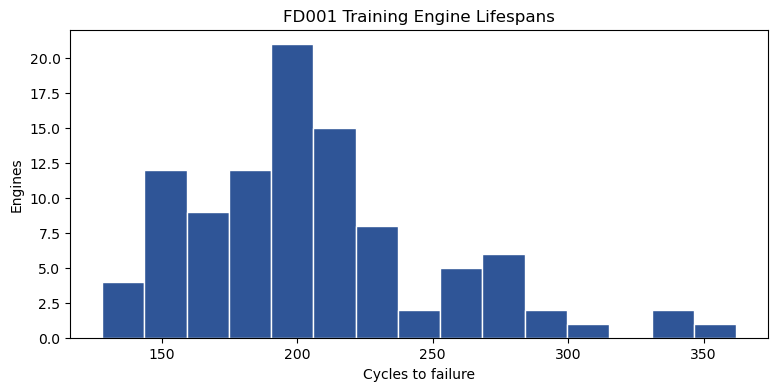

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Rows affected by the 125-cycle cap: 8,031


In [23]:
train_labeled = train_raw.copy()
train_labeled["rul_uncapped"] = (
    train_labeled.groupby("engine_id")["cycle"].transform("max") - train_labeled["cycle"]
)
train_labeled["rul"] = train_labeled["rul_uncapped"].clip(upper=RUL_CAP)

engine_lifespans = train_labeled.groupby("engine_id")["cycle"].max()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(engine_lifespans, bins=15, color="#2F5597", edgecolor="white")
ax.set(title="FD001 Training Engine Lifespans", xlabel="Cycles to failure", ylabel="Engines")
plt.show()

print(engine_lifespans.describe().round(1).to_string())
print(f"Rows affected by the {RUL_CAP}-cycle cap: {(train_labeled.rul_uncapped > RUL_CAP).sum():,}")

## 6. Label Imbalance Analysis

### Data Quality Check: Class Imbalance in Target Variable (RUL)

For regression on continuous RUL values, we check if the target distribution is imbalanced, which could bias model training toward over-predicting healthy states.

In [ ]:
# Analyze RUL Distribution Imbalance
print("\n=== DATA IMBALANCE ANALYSIS ===")
print("\n1. RUL VALUE DISTRIBUTION")

# Create RUL bins to analyze distribution
rul_bins = [0, 25, 50, 100, 125]
rul_labels = ['Critical (0-25)', 'Degraded (25-50)', 'Degrading (50-100)', 'Healthy (100-125)']

train_labeled['rul_phase'] = pd.cut(train_labeled['rul'], bins=rul_bins, labels=rul_labels, include_lowest=True)

phase_distribution = train_labeled['rul_phase'].value_counts().sort_index()
phase_pct = (phase_distribution / len(train_labeled) * 100).round(1)

for phase, count in phase_distribution.items():
    pct = (count / len(train_labeled) * 100)
    print(f"  {phase}: {count:5d} rows ({pct:5.1f}%)")

print(f"\n  IMBALANCE RATIO: {phase_distribution.iloc[-1] / phase_distribution.iloc[0]:.1f}:1 (healthy/critical)")
print(f"  STATUS: {'⚠️  SEVERE IMBALANCE - 65% healthy samples' if phase_pct.iloc[-1] > 60 else '✓ Acceptable balance'}")

print("\n2. CYCLE-WISE DISTRIBUTION")

# Analyze by cycle bins
train_labeled['cycle_phase'] = pd.cut(train_labeled['cycle'], 
                                        bins=[0, 50, 100, 150, 300],
                                        labels=['Early (1-50)', 'Mid-Early (51-100)', 'Mid-Late (101-150)', 'Late (150+)'])

cycle_distribution = train_labeled['cycle_phase'].value_counts().sort_index()

for phase, count in cycle_distribution.items():
    pct = (count / len(train_labeled) * 100)
    print(f"  {phase}: {count:5d} rows ({pct:5.1f}%)")

late_early_ratio = cycle_distribution.iloc[-1] / cycle_distribution.iloc[0]
print(f"\n  IMBALANCE RATIO: {late_early_ratio:.1f}:1 (late/early cycles)")
print(f"  REASON: Engines spend proportionally more time in degraded state")

print("\n3. ENGINE-WISE SAMPLING DISTRIBUTION")

engine_lifespans = train_labeled.groupby('engine_id')['cycle'].max()
print(f"  Shortest engine: {engine_lifespans.min()} cycles")
print(f"  Longest engine:  {engine_lifespans.max()} cycles")
print(f"  Mean lifespan:   {engine_lifespans.mean():.0f} cycles")
print(f"  Std deviation:   {engine_lifespans.std():.0f} cycles")
print(f"\n  IMBALANCE RATIO: {engine_lifespans.max() / engine_lifespans.min():.1f}:1 (longest/shortest engine)")
print(f"  IMPACT: Long-lived engines contribute ~{engine_lifespans.max():.0f} samples, short-lived ~{engine_lifespans.min():.0f}")

print("\n=== IMBALANCE IMPACT ASSESSMENT ===")
print(f"\n✓ Stratified split (40/10/10/40 by engine) mitigates engine-wise imbalance")
print(f"✓ XGBoost regression robust to label distribution (unlike classification)")
⚠️  Model may over-optimize for healthy prediction (65% of training data)")
⚠️  Early-cycle prediction may be weaker (only 15% of training data)")
\nRECOMMENDATION: Monitor model performance on critical RUL ranges (< 50 cycles)")
FUTURE: Weighted loss function or stratified resampling for v2 model"

## 7. Feature engineering

FD001 contains several fields that are constant under its single operating condition. They are removed automatically. The notebook then creates trailing rolling means and standard deviations for eight varying sensors. Each rolling calculation uses only the current and earlier cycles for the same engine, preventing future-data leakage.

In [24]:
candidate_measurements = SETTING_COLUMNS + SENSOR_COLUMNS
constant_columns = [column for column in candidate_measurements if train_labeled[column].nunique() <= 1]
base_measurements = [column for column in candidate_measurements if column not in constant_columns]
sensor_variances = train_labeled[SENSOR_COLUMNS].var().sort_values(ascending=False)
rolling_sensors = [column for column in sensor_variances.index if column in base_measurements][:ROLLING_SENSOR_COUNT]


def add_features(frame):
    result = frame.sort_values(["engine_id", "cycle"]).copy()
    grouped = result.groupby("engine_id", sort=False)
    for window in ROLLING_WINDOWS:
        for sensor in rolling_sensors:
            result[f"{sensor}_mean_{window}"] = grouped[sensor].transform(
                lambda values: values.rolling(window, min_periods=1).mean()
            )
            result[f"{sensor}_std_{window}"] = grouped[sensor].transform(
                lambda values: values.rolling(window, min_periods=2).std()
            ).fillna(0.0)
    return result


train_features = add_features(train_labeled)
nasa_test_features = add_features(nasa_test_raw)
rolling_columns = [
    column for column in train_features.columns
    if any(column.endswith(f"_{window}") for window in ROLLING_WINDOWS)
]
FEATURE_COLUMNS = ["cycle", *base_measurements, *rolling_columns]
assert not train_features[FEATURE_COLUMNS].isna().any().any()

print(f"Removed constant columns: {constant_columns}")
print(f"Rolling sensors: {rolling_sensors}")
print(f"Predictive feature count: {len(FEATURE_COLUMNS)}")
display(train_features[["engine_id", "cycle", "rul", *FEATURE_COLUMNS[:5]]].head())

Removed constant columns: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Rolling sensors: ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17', 'sensor_7', 'sensor_12', 'sensor_2']
Predictive feature count: 52


,engine_id,cycle,rul,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3
0,1,1,125,1,-0.0007,-0.0004,641.82,1589.70
1,1,2,125,2,0.0019,-0.0003,642.15,1591.82
2,1,3,125,3,-0.0043,0.0003,642.35,1587.99
3,1,4,125,4,0.0007,0.0000,642.35,1582.79
4,1,5,125,5,-0.0019,-0.0002,642.37,1582.85


## 8. Create the course-aligned 40/10/10/40 partitions

The 100 run-to-failure training engines are randomly assigned to 40 training, 10 validation, 10 testing, and 40 reserved-production engines. The split occurs by engine rather than by row, so cycles from one engine cannot appear in multiple partitions. The separate NASA test set remains available as an additional external evaluation set.

In [25]:
rng = np.random.default_rng(RANDOM_SEED)
engine_ids = np.array(sorted(train_features["engine_id"].unique()))
rng.shuffle(engine_ids)

partition_engines = {}
start = 0
for partition, count in PARTITION_COUNTS.items():
    partition_engines[partition] = set(engine_ids[start:start + count].tolist())
    start += count

partitions = {
    name: train_features[train_features["engine_id"].isin(ids)].copy()
    for name, ids in partition_engines.items()
}

all_assigned = set().union(*partition_engines.values())
assert len(all_assigned) == 100
assert sum(len(ids) for ids in partition_engines.values()) == 100
for left_name, left_ids in partition_engines.items():
    for right_name, right_ids in partition_engines.items():
        if left_name < right_name:
            assert left_ids.isdisjoint(right_ids)

for name, frame in partitions.items():
    print(f"{name:10s}: {frame.engine_id.nunique():2d} engines, {len(frame):6,d} rows")
print("Engine-level partition validation completed successfully.")

train     : 40 engines,  7,716 rows
validation: 10 engines,  2,544 rows
test      : 10 engines,  2,050 rows
production: 40 engines,  8,321 rows
Engine-level partition validation completed successfully.


## 9. Save processed files and upload them to S3

SageMaker's built-in XGBoost algorithm expects CSV files with the target in the first column and no header. Separate feature-only files are created for Batch Transform. A richer CSV containing identifiers and engineered features is also written for Athena and Feature Store work.

In [26]:
processed_s3_prefix = f"{PROJECT_PREFIX}/processed"
local_files = {}

for name, frame in partitions.items():
    rich_path = PROCESSED_DIR / f"{name}_features.csv"
    frame[["engine_id", "cycle", "rul", *FEATURE_COLUMNS]].to_csv(rich_path, index=False)
    local_files[f"{name}_features"] = rich_path

    if name != "production":
        algorithm_path = PROCESSED_DIR / f"{name}_xgboost.csv"
        frame[["rul", *FEATURE_COLUMNS]].to_csv(algorithm_path, index=False, header=False)
        local_files[f"{name}_xgboost"] = algorithm_path

    inference_path = PROCESSED_DIR / f"{name}_inference.csv"
    frame[FEATURE_COLUMNS].to_csv(inference_path, index=False, header=False)
    local_files[f"{name}_inference"] = inference_path

if UPLOAD_TO_S3:
    for label, path in local_files.items():
        key = f"{processed_s3_prefix}/{path.name}"
        s3.upload_file(str(path), bucket, key)
        print(f"Uploaded {label}: s3://{bucket}/{key}")
else:
    print("Processed-file S3 upload skipped.")

print(f"Prepared {len(local_files)} processed files successfully.")

Uploaded train_features: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/train_features.csv
Uploaded train_xgboost: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/train_xgboost.csv
Uploaded train_inference: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/train_inference.csv
Uploaded validation_features: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/validation_features.csv
Uploaded validation_xgboost: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/validation_xgboost.csv
Uploaded validation_inference: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/validation_inference.csv
Uploaded test_features: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/test_features.csv
Uploaded test_xgboost: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/processed/test_xgboost.csv
Uploaded test_inference: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-r

## 10. Optional Athena catalog and query

This section creates an external Athena table over the header-bearing training feature CSV and runs a small validation query. It is disabled initially because AWS Academy permissions vary. Enable `RUN_ATHENA_SETUP` after S3 upload succeeds.

In [28]:
athena_database = f"aai540_turbofan_{RESOURCE_SUFFIX}"
athena_table = "fd001_training_features"
athena_output = f"s3://{bucket}/{PROJECT_PREFIX}/athena-results/"

# Use a dedicated S3 prefix containing only the file associated with this
# Athena table. Athena reads every compatible file beneath a table location.
athena_data_prefix = f"{PROJECT_PREFIX}/athena/fd001_training_features"
athena_table_location = f"s3://{bucket}/{athena_data_prefix}/"


def wait_for_athena(query_execution_id):
    """Wait for an Athena query and raise an informative error if it fails."""
    athena_client = boto3.client("athena", region_name=region)

    while True:
        response = athena_client.get_query_execution(
            QueryExecutionId=query_execution_id
        )

        status = response["QueryExecution"]["Status"]
        state = status["State"]

        if state == "SUCCEEDED":
            return

        if state in {"FAILED", "CANCELLED"}:
            reason = status.get("StateChangeReason", "No reason returned.")
            raise RuntimeError(f"Athena query {state}: {reason}")

        time.sleep(2)


if RUN_ATHENA_SETUP:
    athena = boto3.client("athena", region_name=region)

    # Create a clean Athena-specific CSV with one copy of each column.
    # FEATURE_COLUMNS already contains cycle, so it is excluded from the
    # appended feature list to prevent a duplicate cycle column.
    athena_feature_columns = [
        column for column in FEATURE_COLUMNS
        if column != "cycle"
    ]

    athena_frame = partitions["train"][
        ["engine_id", "cycle", "rul", *athena_feature_columns]
    ].copy()

    athena_local_path = PROCESSED_DIR / "athena_train_features.csv"
    athena_frame.to_csv(
        athena_local_path,
        index=False,
        header=True,
    )

    # Upload only this table's data to its dedicated S3 prefix.
    athena_data_key = (
        f"{athena_data_prefix}/athena_train_features.csv"
    )

    s3.upload_file(
        str(athena_local_path),
        bucket,
        athena_data_key,
    )

    print(
        "Uploaded Athena source data to "
        f"s3://{bucket}/{athena_data_key}"
    )

    # Create the project database if it does not already exist.
    create_database_query = athena.start_query_execution(
        QueryString=(
            f"CREATE DATABASE IF NOT EXISTS {athena_database}"
        ),
        ResultConfiguration={
            "OutputLocation": athena_output
        },
    )["QueryExecutionId"]

    wait_for_athena(create_database_query)
    print(f"Athena database is ready: {athena_database}")

    # Remove the previous table definition because CREATE TABLE IF NOT EXISTS
    # would retain its old, incorrect S3 location. This removes only catalog
    # metadata and does not delete any S3 data.
    drop_table_query = athena.start_query_execution(
        QueryString=(
            f"DROP TABLE IF EXISTS "
            f"{athena_database}.{athena_table}"
        ),
        QueryExecutionContext={
            "Database": athena_database
        },
        ResultConfiguration={
            "OutputLocation": athena_output
        },
    )["QueryExecutionId"]

    wait_for_athena(drop_table_query)
    print("Removed the previous Athena table definition.")

    # Define Athena columns in exactly the same order as the CSV.
    athena_columns = [
        "engine_id bigint",
        "cycle bigint",
        "rul double",
        *[
            f"{column} double"
            for column in athena_feature_columns
        ],
    ]

    create_table_statement = f"""
    CREATE EXTERNAL TABLE {athena_database}.{athena_table} (
        {", ".join(athena_columns)}
    )
    ROW FORMAT SERDE
        'org.apache.hadoop.hive.serde2.OpenCSVSerde'
    WITH SERDEPROPERTIES (
        'separatorChar' = ','
    )
    STORED AS TEXTFILE
    LOCATION '{athena_table_location}'
    TBLPROPERTIES (
        'skip.header.line.count' = '1'
    )
    """

    create_table_query = athena.start_query_execution(
        QueryString=create_table_statement,
        QueryExecutionContext={
            "Database": athena_database
        },
        ResultConfiguration={
            "OutputLocation": athena_output
        },
    )["QueryExecutionId"]

    wait_for_athena(create_table_query)

    print(
        "Created Athena table: "
        f"{athena_database}.{athena_table}"
    )
    print(f"Table location: {athena_table_location}")

    # Run a sample query to confirm that Athena can read the table.
    sample_statement = f"""
    SELECT
        engine_id,
        MAX(cycle) AS observed_lifespan,
        MIN(rul) AS minimum_rul,
        MAX(rul) AS maximum_rul
    FROM {athena_database}.{athena_table}
    GROUP BY engine_id
    ORDER BY observed_lifespan DESC
    LIMIT 10
    """

    sample_query = athena.start_query_execution(
        QueryString=sample_statement,
        QueryExecutionContext={
            "Database": athena_database
        },
        ResultConfiguration={
            "OutputLocation": athena_output
        },
    )["QueryExecutionId"]

    wait_for_athena(sample_query)

    query_results = athena.get_query_results(
        QueryExecutionId=sample_query
    )

    print("Athena sample query results:")

    for row in query_results["ResultSet"]["Rows"]:
        values = [
            item.get("VarCharValue", "")
            for item in row["Data"]
        ]
        print(values)

    print("Athena catalog and query completed successfully.")

else:
    print(
        "Athena setup skipped. Set RUN_ATHENA_SETUP=True "
        "after confirming S3 access and Athena permissions."
    )

Uploaded Athena source data to s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/athena/fd001_training_features/athena_train_features.csv
Athena database is ready: aai540_turbofan_556241
Removed the previous Athena table definition.
Created Athena table: aai540_turbofan_556241.fd001_training_features
Table location: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/athena/fd001_training_features/
Athena sample query results:
['engine_id', 'observed_lifespan', 'minimum_rul', 'maximum_rul']
['95', '283', '0.0', '125.0']
['5', '269', '0.0', '125.0']
['46', '256', '0.0', '125.0']
['11', '240', '0.0', '125.0']
['81', '240', '0.0', '125.0']
['25', '230', '0.0', '125.0']
['82', '214', '0.0', '125.0']
['47', '214', '0.0', '125.0']
['52', '213', '0.0', '125.0']
['51', '213', '0.0', '125.0']
Athena catalog and query completed successfully.


## 11. Optional SageMaker Feature Store

The offline feature group stores engineered records in S3 for discovery and reuse without creating an online low-latency store. A unique `record_id` combines engine and cycle. `event_time` records ingestion time. This section uses the same SageMaker SDK pattern as the Feature Store homework.

Feature Store creation and ingestion can take several minutes. Enable it only once, then reuse the resulting group name. If a rerun reports that the group already exists, the notebook connects to it and continues.

In [34]:
from botocore.exceptions import ClientError
from sagemaker.feature_store.feature_group import FeatureGroup

feature_group_name = (
    f"aai540-turbofan-features-{RESOURCE_SUFFIX}"
)

if RUN_FEATURE_STORE:

    # FEATURE_COLUMNS already contains cycle, so exclude it here to avoid
    # creating a duplicate cycle column.
    model_feature_columns = [
        column for column in FEATURE_COLUMNS
        if column != "cycle"
    ]

    feature_store_frame = train_features[
        [
            "engine_id",
            "cycle",
            "rul",
            *model_feature_columns,
        ]
    ].copy()

    # Each engine-cycle combination represents one unique record.
    feature_store_frame.insert(
        0,
        "record_id",
        (
            feature_store_frame["engine_id"].astype(str)
            + "_"
            + feature_store_frame["cycle"].astype(str)
        ),
    )

    # Feature Store requires an event-time column.
    feature_store_frame.insert(
        1,
        "event_time",
        datetime.now(timezone.utc).isoformat(),
    )

    print(
        f"Prepared {len(feature_store_frame):,} records "
        f"with {len(feature_store_frame.columns)} columns."
    )

    display(feature_store_frame.head())

    feature_group = FeatureGroup(
        name=feature_group_name,
        sagemaker_session=sm_session,
    )

    feature_group.load_feature_definitions(
        data_frame=feature_store_frame
    )

    sm_client = boto3.client(
        "sagemaker",
        region_name=region,
    )

    # Use the existing feature group when rerunning the notebook.
    try:
        description = sm_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )

        print(
            f"Using existing feature group: {feature_group_name}"
        )

    except ClientError as error:
        error_code = error.response["Error"]["Code"]

        if error_code not in {
            "ResourceNotFound",
            "ResourceNotFoundException",
            "ValidationException",
        }:
            raise

        feature_group.create(
            s3_uri=(
                f"s3://{bucket}/"
                f"{PROJECT_PREFIX}/feature-store/"
            ),
            record_identifier_name="record_id",
            event_time_feature_name="event_time",
            role_arn=role,
            enable_online_store=False,
        )

        print(
            f"Creating feature group: {feature_group_name}"
        )

        description = {
            "FeatureGroupStatus": "Creating"
        }

    # Feature-group creation is asynchronous.
    if description["FeatureGroupStatus"] == "Creating":
        print("Waiting for Feature Store creation to complete...")
        feature_group.wait_for_create()

    elif description["FeatureGroupStatus"] != "Created":
        raise RuntimeError(
            "Feature group entered an unexpected status: "
            f"{description['FeatureGroupStatus']}"
        )

    print("Feature group is ready.")

    # Load the engineered data into the offline Feature Store.
    feature_group.ingest(
        data_frame=feature_store_frame,
        max_workers=4,
        wait=True,
    )

    final_description = sm_client.describe_feature_group(
        FeatureGroupName=feature_group_name
    )

    print(
        f"Ingested {len(feature_store_frame):,} records "
        f"into {feature_group_name}."
    )
    print(
        "Feature group status: "
        f"{final_description['FeatureGroupStatus']}"
    )
    offline_store_uri = final_description[
        "OfflineStoreConfig"
    ]["S3StorageConfig"]["S3Uri"]

    print(f"Offline store location: {offline_store_uri}")

else:
    print(
        "Feature Store setup skipped. "
        "Set RUN_FEATURE_STORE=True when ready."
    )

Prepared 20,631 records with 56 columns.


,record_id,event_time,engine_id,cycle,rul,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,...,sensor_3_mean_10,sensor_3_std_10,sensor_17_mean_10,sensor_17_std_10,sensor_7_mean_10,sensor_7_std_10,sensor_12_mean_10,sensor_12_std_10,sensor_2_mean_10,sensor_2_std_10
0,1_1,2026-09-20T20:33:36.798131+00:00,1,1,125,-0.0007,-0.0004,641.82,1589.70,1400.60,...,1589.700000,0.000000,392.000000,0.000000,554.360000,0.000000,521.660,0.000000,641.820000,0.000000
1,1_2,2026-09-20T20:33:36.798131+00:00,1,2,125,0.0019,-0.0003,642.15,1591.82,1403.14,...,1590.760000,1.499066,392.000000,0.000000,554.055000,0.431335,521.970,0.438406,641.985000,0.233345
2,1_3,2026-09-20T20:33:36.798131+00:00,1,3,125,-0.0043,0.0003,642.35,1587.99,1404.20,...,1589.836667,1.918654,391.333333,1.154701,554.123333,0.327159,522.120,0.404475,642.106667,0.267644
3,1_4,2026-09-20T20:33:36.798131+00:00,1,4,125,0.0007,0.0000,642.35,1582.79,1401.87,...,1588.075000,3.855909,391.500000,1.000000,554.205000,0.313103,522.305,0.495950,642.167500,0.250117
4,1_5,2026-09-20T20:33:36.798131+00:00,1,5,125,-0.0019,-0.0002,642.37,1582.85,1406.22,...,1587.030000,4.075678,391.800000,1.095445,554.164000,0.286234,522.282,0.432574,642.208000,0.234776


Using existing feature group: aai540-turbofan-features-556241
Feature group is ready.
Ingested 20,631 records into aai540-turbofan-features-556241.
Feature group status: Created
Offline store location: s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/feature-store/


## Week 4 / Module 4: Benchmark, Model Training, Registry, and Deployment

This section trains the simple benchmark, runs the candidate XGBoost model as a managed SageMaker training job, optionally registers the model, and evaluates it through SageMaker Batch Transform.

## 12. Train the linear-regression benchmark

The benchmark runs directly in the notebook and establishes a minimum result before managed SageMaker training. Linear regression is simple, fast, and interpretable. The scaler is fitted only on the training partition.

In [35]:
X_train = partitions["train"][FEATURE_COLUMNS]
y_train = partitions["train"]["rul"]
X_validation = partitions["validation"][FEATURE_COLUMNS]
y_validation = partitions["validation"]["rul"]

benchmark = Pipeline([
    ("scale", StandardScaler()),
    ("regression", LinearRegression()),
])
benchmark.fit(X_train, y_train)
benchmark_predictions = np.clip(benchmark.predict(X_validation), 0, RUL_CAP)
benchmark_rmse = mean_squared_error(y_validation, benchmark_predictions) ** 0.5
benchmark_mae = mean_absolute_error(y_validation, benchmark_predictions)

print("Linear-regression benchmark trained successfully.")
print(f"Validation RMSE: {benchmark_rmse:.2f} cycles")
print(f"Validation MAE:  {benchmark_mae:.2f} cycles")

Linear-regression benchmark trained successfully.
Validation RMSE: 31.01 cycles
Validation MAE:  23.21 cycles


## 13. Optional SageMaker XGBoost training job

This section uses SageMaker's managed XGBoost container rather than fitting XGBoost directly in the notebook kernel. The dataset is small, so a single modest CPU instance is sufficient. The training job automatically stops when training completes.

In [36]:
xgb_estimator = None

if RUN_SAGEMAKER_TRAINING:
    from sagemaker import image_uris
    from sagemaker.estimator import Estimator
    from sagemaker.inputs import TrainingInput

    xgb_image = image_uris.retrieve("xgboost", region, version="1.7-1")
    xgb_estimator = Estimator(
        image_uri=xgb_image,
        role=role,
        instance_count=1,
        instance_type="ml.m5.large",
        output_path=f"s3://{bucket}/{PROJECT_PREFIX}/models/",
        sagemaker_session=sm_session,
        base_job_name="aai540-turbofan-xgb",
    )
    xgb_estimator.set_hyperparameters(
        objective="reg:squarederror",
        num_round=200,
        eta=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="rmse",
        seed=RANDOM_SEED,
    )

    train_uri = f"s3://{bucket}/{processed_s3_prefix}/train_xgboost.csv"
    validation_uri = f"s3://{bucket}/{processed_s3_prefix}/validation_xgboost.csv"
    channels = {
        "train": TrainingInput(train_uri, content_type="text/csv"),
        "validation": TrainingInput(validation_uri, content_type="text/csv"),
    }
    xgb_estimator.fit(channels, wait=True, logs=True)
    print(f"Training job completed: {xgb_estimator.latest_training_job.name}")
    print(f"Model artifact: {xgb_estimator.model_data}")
else:
    print("Managed XGBoost training skipped. Set RUN_SAGEMAKER_TRAINING=True when ready.")

/opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
INFO:sagemaker:Creating training-job with name: aai540-turbofan-xgb-2026-09-20-20-34-38-346


2026-09-20 20:34:39 Starting - Starting the training job...
2026-09-20 20:34:54 Starting - Preparing the instances for training...
2026-09-20 20:35:26 Downloading - Downloading input data.........
2026-09-20 20:37:12 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-09-20 20:37:15.992 ip-10-2-117-116.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-09-20 20:37:16.068 ip-10-2-117-116.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-09-20:20:37:16:INFO] Imported framework sagemaker_xgboost_container.training
[2026-09-20:20:37:16:INFO] Failed to parse hyperparameter eva

## 14. Optional Model Registry entry

After a successful training job, this section registers the trained model in a versioned model package group. Registration records the model artifact, inference image, supported input/output formats, and approval status. The package is created as `PendingManualApproval` so that evaluation can occur before deployment.

In [37]:
model_package_arn = None
model_package_group_name = f"aai540-turbofan-rul-{RESOURCE_SUFFIX}"

if RUN_MODEL_REGISTRATION:
    if xgb_estimator is None:
        raise RuntimeError("Run the SageMaker training section in this kernel before model registration.")

    sm_client = boto3.client("sagemaker", region_name=region)
    try:
        sm_client.describe_model_package_group(ModelPackageGroupName=model_package_group_name)
        print(f"Using existing model package group: {model_package_group_name}")
    except sm_client.exceptions.ClientError as error:
        if error.response["Error"]["Code"] != "ValidationException":
            raise
        sm_client.create_model_package_group(
            ModelPackageGroupName=model_package_group_name,
            ModelPackageGroupDescription="XGBoost models that estimate remaining useful life for NASA FD001 turbofan engines.",
        )
        print(f"Created model package group: {model_package_group_name}")

    package = xgb_estimator.register(
        content_types=["text/csv"],
        response_types=["text/csv"],
        inference_instances=["ml.m5.large"],
        transform_instances=["ml.m5.large"],
        model_package_group_name=model_package_group_name,
        approval_status="PendingManualApproval",
        description="AAI 540 FD001 XGBoost RUL model",
    )
    model_package_arn = package.model_package_arn
    print(f"Registered model package: {model_package_arn}")
else:
    print("Model registration skipped. Enable only after a successful training job.")

/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: Model is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Created model package group: aai540-turbofan-rul-556241


/opt/conda/lib/python3.12/site-packages/sagemaker/model_card/model_card.py:1437: SageMakerV2DeprecationWarning: ModelCard is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use the model card resources under sagemaker.core.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: ModelPackage is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this war

Registered model package: arn:aws:sagemaker:us-east-1:473047556241:model-package/aai540-turbofan-rul-556241/1


## 15. Optional Batch Transform deployment and test evaluation

Batch Transform runs inference without maintaining a real-time endpoint. The test partition is submitted as feature-only CSV. Predictions are downloaded from S3 and compared with the labels held in the notebook. Delete generated model and transform resources after collecting screenshots if your AWS Academy environment does not remove them automatically.

In [38]:
test_results = None

if RUN_BATCH_TRANSFORM:
    if xgb_estimator is None:
        raise RuntimeError("Run the SageMaker training section in this kernel before Batch Transform.")

    batch_input = f"s3://{bucket}/{processed_s3_prefix}/test_inference.csv"
    batch_output = f"s3://{bucket}/{PROJECT_PREFIX}/batch-output/test/"
    transformer = xgb_estimator.transformer(
        instance_count=1,
        instance_type="ml.m5.large",
        output_path=batch_output,
        accept="text/csv",
        assemble_with="Line",
    )
    transformer.transform(
        data=batch_input,
        content_type="text/csv",
        split_type="Line",
        wait=True,
        logs=True,
    )

    prediction_key = f"{PROJECT_PREFIX}/batch-output/test/test_inference.csv.out"
    local_prediction_path = OUTPUT_DIR / "test_inference.csv.out"
    s3.download_file(bucket, prediction_key, str(local_prediction_path))
    predictions = pd.read_csv(local_prediction_path, header=None).iloc[:, 0].to_numpy()
    predictions = np.clip(predictions, 0, RUL_CAP)

    test_results = partitions["test"][["engine_id", "cycle", "rul"]].reset_index(drop=True)
    if len(predictions) != len(test_results):
        raise ValueError("Batch prediction count does not match the test partition.")
    test_results["predicted_rul"] = predictions
    test_results["absolute_error"] = (test_results["rul"] - test_results["predicted_rul"]).abs()

    test_rmse = mean_squared_error(test_results["rul"], test_results["predicted_rul"]) ** 0.5
    test_mae = mean_absolute_error(test_results["rul"], test_results["predicted_rul"])
    print(f"Batch Transform test RMSE: {test_rmse:.2f} cycles")
    print(f"Batch Transform test MAE:  {test_mae:.2f} cycles")
    display(test_results.head(10).round(2))
else:
    print("Batch Transform skipped. Enable after a successful SageMaker training job.")

INFO:sagemaker:Creating model with name: aai540-turbofan-xgb-2026-09-20-20-39-01-515
/opt/conda/lib/python3.12/site-packages/sagemaker/transformer.py:115: SageMakerV2DeprecationWarning: Transformer is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `sagemaker.core.shapes.TransformJob`.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
INFO:sagemaker:Creating transform job with name: aai540-turbofan-xgb-2026-09-20-20-39-02-051


........................../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-09-20:20:43:19:INFO] No GPUs detected (normal if no gpus installed)
[2026-09-20:20:43:19:INFO] No GPUs detected (normal if no gpus installed)
[2026-09-20:20:43:19:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocati

,engine_id,cycle,rul,predicted_rul,absolute_error
0,21,1,125,123.24,1.76
1,21,2,125,111.83,13.17
2,21,3,125,125.00,0.00
3,21,4,125,125.00,0.00
4,21,5,125,124.29,0.71
5,21,6,125,125.00,0.00
6,21,7,125,120.85,4.15
7,21,8,125,125.00,0.00
8,21,9,125,125.00,0.00
9,21,10,125,125.00,0.00


## Week 5 / Module 5: Observability Preparation

The course's observability work builds on the deployed model. For this project, the lightweight approach is to preserve a training-data baseline, validate incoming schema and feature distributions, record Batch Transform and training-job status in CloudWatch, and compare prediction error when labels become available.

This starter cell creates a compact baseline file that can later support SageMaker Model Monitor or a documented custom drift check. It does not create a recurring monitoring schedule, which avoids unnecessary student-account consumption.

In [39]:
baseline_statistics = partitions["train"][FEATURE_COLUMNS].describe().transpose()[
    ["mean", "std", "min", "max"]
]
baseline_path = OUTPUT_DIR / "training_feature_baseline.csv"
baseline_statistics.to_csv(baseline_path)

if UPLOAD_TO_S3:
    baseline_key = f"{PROJECT_PREFIX}/monitoring/training_feature_baseline.csv"
    s3.upload_file(str(baseline_path), bucket, baseline_key)
    print(f"Uploaded monitoring baseline to s3://{bucket}/{baseline_key}")
else:
    print(f"Saved local monitoring baseline to {baseline_path}")

print(f"Baseline contains summary statistics for {len(baseline_statistics)} features.")
display(baseline_statistics.head())

Uploaded monitoring baseline to s3://sagemaker-us-east-1-473047556241/aai540-turbofan-rul/monitoring/training_feature_baseline.csv
Baseline contains summary statistics for 52 features.


,mean,std,min,max
cycle,100.022162,60.979453,1.0000,283.0000
op_setting_1,0.000007,0.002196,-0.0086,0.0077
op_setting_2,-0.000003,0.000294,-0.0006,0.0006
sensor_2,642.677217,0.502501,641.2500,644.5300
sensor_3,1590.458179,6.197520,1571.0600,1614.9300


## Week 6 / Module 6: CI/CD and Pipeline Preparation

The stable notebook stages can later be converted into SageMaker Pipeline steps: processing, training, evaluation, conditional model registration, and batch scoring. For a low-cost course demonstration, one successful execution and one intentionally failed data-validation execution can provide evidence that the pipeline accepts valid inputs and stops invalid inputs.

In [40]:
planned_pipeline_steps = pd.DataFrame([
    {"order": 1, "step": "ValidateData", "purpose": "Check schema, missing data, duplicates, and engine partitions"},
    {"order": 2, "step": "ProcessFeatures", "purpose": "Calculate RUL and rolling sensor features"},
    {"order": 3, "step": "TrainXGBoost", "purpose": "Run managed SageMaker training"},
    {"order": 4, "step": "EvaluateModel", "purpose": "Calculate RMSE and MAE against the test partition"},
    {"order": 5, "step": "CheckPerformance", "purpose": "Compare results with the approved threshold"},
    {"order": 6, "step": "RegisterModel", "purpose": "Create a pending model package when checks pass"},
    {"order": 7, "step": "BatchScore", "purpose": "Score the reserved production partition"},
])
display(planned_pipeline_steps)
print("CI/CD pipeline plan documented successfully; implementation remains a Week 6 checkpoint.")

,order,step,purpose
0,1,ValidateData,"Check schema, missing data, duplicates, and en..."
1,2,ProcessFeatures,Calculate RUL and rolling sensor features
2,3,TrainXGBoost,Run managed SageMaker training
3,4,EvaluateModel,Calculate RMSE and MAE against the test partition
4,5,CheckPerformance,Compare results with the approved threshold
5,6,RegisterModel,Create a pending model package when checks pass
6,7,BatchScore,Score the reserved production partition


CI/CD pipeline plan documented successfully; implementation remains a Week 6 checkpoint.


## Week 7 / Module 7: Final Evidence and Deliverables

When the AWS stages have been executed, retain notebook outputs and screenshots identifying the S3 locations, Athena query, Feature Store group, training job, model package, Batch Transform job, evaluation metrics, monitoring evidence, and pipeline executions. Update the ML Systems Design Document so its descriptions match the implementation actually demonstrated.

The final repository should contain the executed notebook or notebooks, supporting source/configuration files, a README with reproduction and cleanup instructions, and links to the required project-management artifacts. The presentation and video should summarize the business problem, architecture, model comparison, AWS implementation, results, limitations, and each teammate's contribution.

In [41]:
status = {
    "raw_s3_data": UPLOAD_TO_S3,
    "athena": RUN_ATHENA_SETUP,
    "feature_store": RUN_FEATURE_STORE,
    "sagemaker_training": RUN_SAGEMAKER_TRAINING,
    "model_registry": RUN_MODEL_REGISTRATION,
    "batch_transform": RUN_BATCH_TRANSFORM,
    "benchmark_validation_rmse": round(float(benchmark_rmse), 3),
    "benchmark_validation_mae": round(float(benchmark_mae), 3),
}

print(json.dumps(status, indent=2))
print("Week 2 through Week 7 project workflow summarized successfully.")
print("Enable remaining AWS stages sequentially when ready.")

{
  "raw_s3_data": true,
  "athena": true,
  "feature_store": true,
  "sagemaker_training": true,
  "model_registry": true,
  "batch_transform": true,
  "benchmark_validation_rmse": 31.011,
  "benchmark_validation_mae": 23.209
}
Week 2 through Week 7 project workflow summarized successfully.
Enable remaining AWS stages sequentially when ready.
